In [4]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
import contextily as ctx

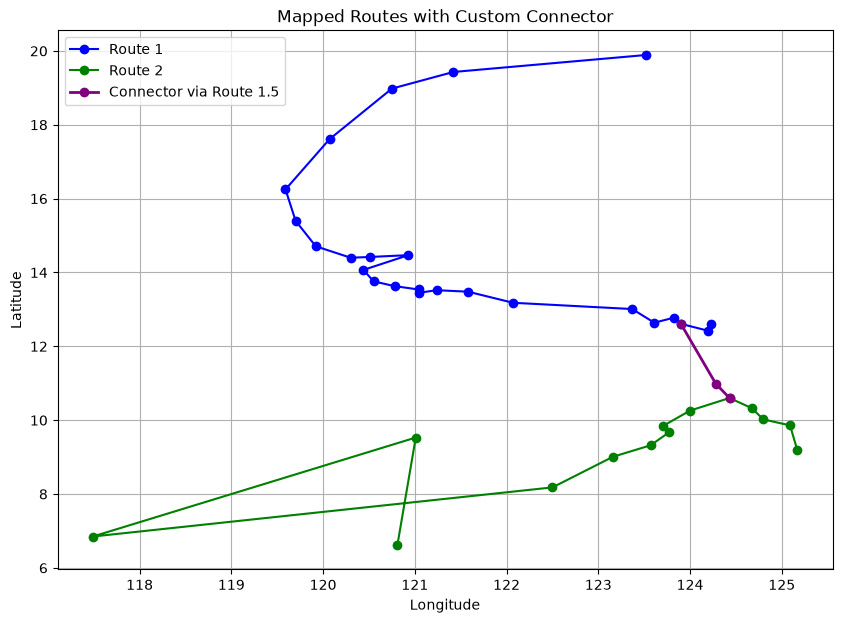

In [41]:
import matplotlib.pyplot as plt

# Data
route = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,
         1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1.5,
         3]
latitude = [19.89,19.43,18.98,17.61,16.25,15.4,14.71,14.40,14.42,14.47,14.07,13.76,13.63,13.54,13.45,13.52,13.48,13.18,13.01,12.64,12.78,12.61,12.42,12.6,
            6.62,9.53,6.85,8.18,9.01,9.32,9.67,9.85,10.26,10.60,10.33,10.02,9.86,9.18,10.99,11.70,
            ]
longitude = [123.52,121.42,120.75,120.07,119.59,119.7,119.92,120.3,120.51,120.93,120.44,120.55,120.78,121.04,121.04,121.24,121.58,122.07,123.37,123.61,123.83,123.90,124.20,124.23,
             120.81,121.01,117.49,122.50,123.16,123.57,123.77,123.71,124.00,124.43,124.67,124.80,125.09,125.17,124.28,124.19,]

# Split by route
route1_lats = [lat for lat, r in zip(latitude, route) if r == 1]
route1_lons = [lon for lon, r in zip(longitude, route) if r == 1]

route2_lats = [lat for lat, r in zip(latitude, route) if r == 2]
route2_lons = [lon for lon, r in zip(longitude, route) if r == 2]

connector_lat = [lat for lat, r in zip(latitude, route) if r == 1.5][0]
connector_lon = [lon for lon, r in zip(longitude, route) if r == 1.5][0]

# Connector: point 14 of Route 1 and point 10 of Route 2
pt14_lat = route1_lats[21]  # 0-based index
pt14_lon = route1_lons[21]

pt10_lat = route2_lats[9]
pt10_lon = route2_lons[9]

# Plot
plt.figure(figsize=(10, 7))

# Route 1
plt.plot(route1_lons, route1_lats, c='blue', linestyle='-', marker='o', label='Route 1')

# Route 2
plt.plot(route2_lons, route2_lats, c='green', linestyle='-', marker='o', label='Route 2')

# Connector Route
connector_lons = [pt14_lon, connector_lon, pt10_lon]
connector_lats = [pt14_lat, connector_lat, pt10_lat]
plt.plot(connector_lons, connector_lats, c='purple', linestyle='-', marker = 'o', linewidth=2, label='Connector via Route 1.5')


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Mapped Routes with Custom Connector')
plt.grid(True)
plt.legend()
plt.show()


In [42]:
nodes = pd.DataFrame({
    "id": list(range(len(latitude))),
    "latitude": latitude,
    "longitude": longitude,
    "route": route
})
nodes.head()

,id,latitude,longitude,route
0,0,19.89,123.52,1.0
1,1,19.43,121.42,1.0
2,2,18.98,120.75,1.0
3,3,17.61,120.07,1.0
4,4,16.25,119.59,1.0


In [43]:
# Basic sequential edges within each route
edges = []

# Route 1
route1_ids = [i for i, r in enumerate(route) if r == 1]
edges += [{"from": route1_ids[i], "to": route1_ids[i+1]} for i in range(len(route1_ids)-1)]

# Route 2
route2_ids = [i for i, r in enumerate(route) if r == 2]
edges += [{"from": route2_ids[i], "to": route2_ids[i+1]} for i in range(len(route2_ids)-1)]

# Connector path: Route 1 pt 14 → Route 1.5 → Route 2 pt 10
edges += [
    {"from": route1_ids[13], "to": len(route)-1},  # 1.5 is last point
    {"from": len(route)-1, "to": route2_ids[9]}
]

edges_df = pd.DataFrame(edges)
edges_df.head()

,from,to
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5


In [44]:
world = gpd.read_file(r"/Users/ram/Library/CloudStorage/Box-Box/Ram_Ximena_Nicole/Indp Research Phillipine Languages/data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")
countries = world[world['ADMIN'].isin(['Philippines', 'Malaysia'])]

In [45]:
from shapely.geometry import box

# Define bounding box around the Philippines
phil_bounds = box(116.5, 4.5, 126.5, 21.0)
cropped = countries.intersection(phil_bounds)

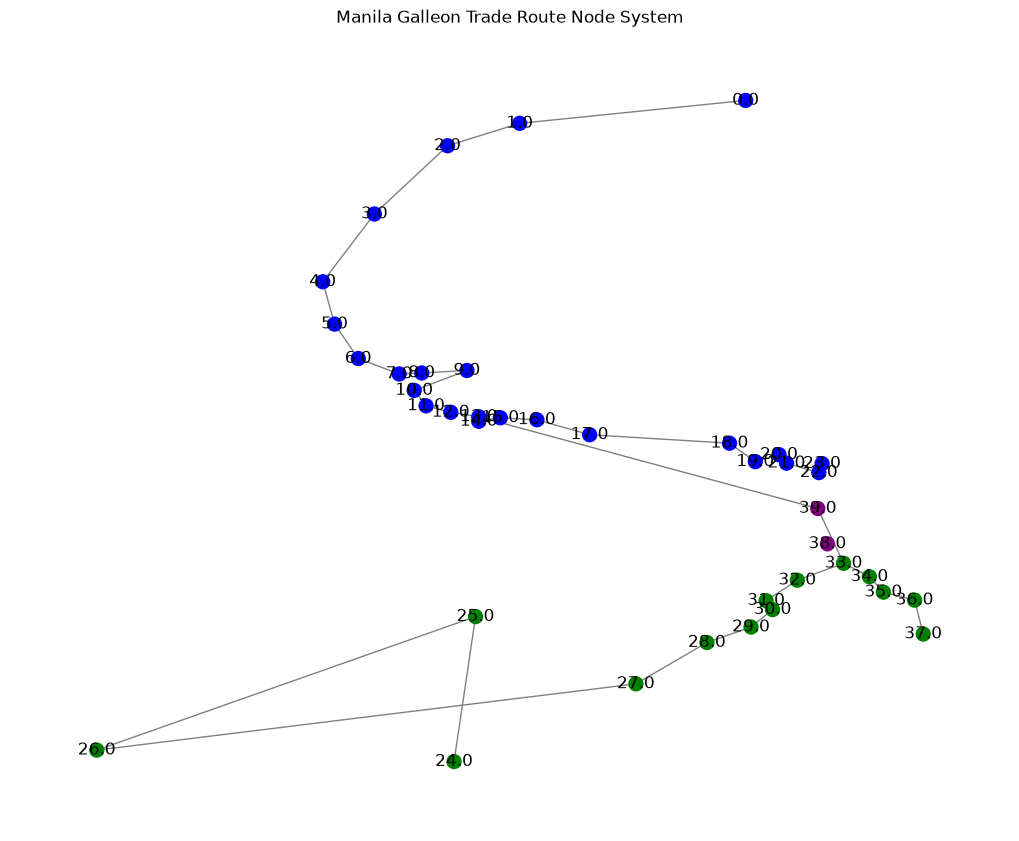

In [46]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Add nodes with position
for _, row in nodes.iterrows():
    G.add_node(row['id'], pos=(row['longitude'], row['latitude']), route=row['route'])

# Add edges
for _, row in edges_df.iterrows():
    G.add_edge(row['from'], row['to'])

# Get positions
pos = nx.get_node_attributes(G, 'pos')

# Color nodes by route
colors = ['blue' if r == 1 else 'green' if r == 2 else 'purple' for r in nodes['route']]

# Plot
plt.figure(figsize=(10, 8))
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=100, edge_color='gray')
plt.title("Manila Galleon Trade Route Node System")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

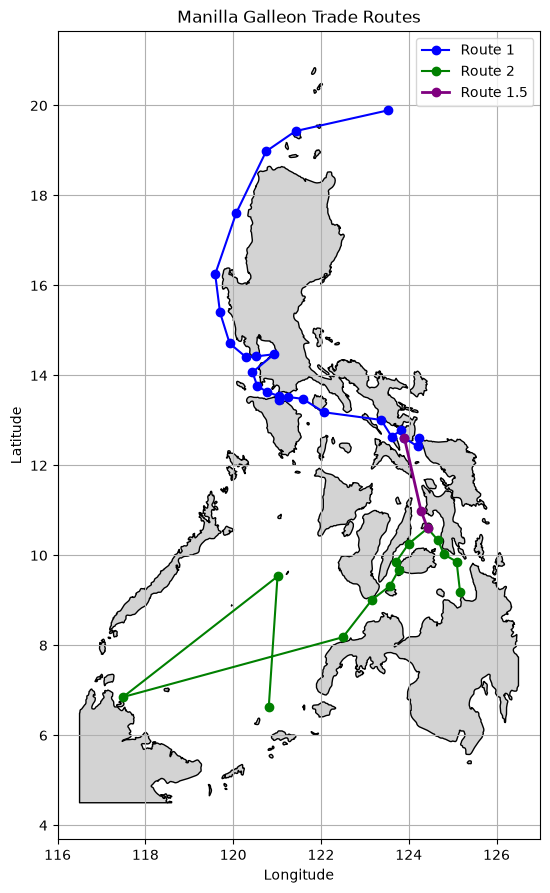

In [47]:
fig, ax = plt.subplots(figsize=(15, 10.5))

# Plot cropped landmass
cropped.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot your sea routes and connector
ax.plot(route1_lons, route1_lats, c='blue', linestyle='-', marker='o', label='Route 1')
ax.plot(route2_lons, route2_lats, c='green', linestyle='-', marker='o', label='Route 2')
ax.plot(connector_lons, connector_lats, c='purple', linestyle='-', marker='o', linewidth=2, label='Route 1.5')

# Labels and legend
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Manilla Galleon Trade Routes')
ax.legend()
ax.grid(True)

plt.show()

In [48]:
nodes.to_csv("/Users/ram/Library/CloudStorage/Box-Box/Ram_Ximena_Nicole/Indp Research Phillipine Languages/data/nodes.csv", index=False)
edges_df.to_csv("/Users/ram/Library/CloudStorage/Box-Box/Ram_Ximena_Nicole/Indp Research Phillipine Languages/data/edges.csv", index=False)